In [7]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

In [8]:
data=pd.read_csv('synthetic_complaints_datechange.csv')
data[10:20]

,complaint_id,text_description,issue_type,department,priority,latitude,longitude,status,created_time,created_date
10,COMP_00011,Overflowing dustbin at Jayanagar,garbage,BBMP Sanitation,Medium,12.972609,77.625961,Pending,15:42:30,2026-11-28
11,COMP_00012,Power outage in MG Road for 8 days,electricity,BESCOM,High,12.980927,77.650195,Pending,15:51:28,2057-07-23
12,COMP_00013,Power outage in Jayanagar for 10 days,electricity,BESCOM,Critical,13.007095,77.600331,In Progress,03:24:49,2073-10-18
13,COMP_00014,Street lights not working at Jayanagar,electricity,BESCOM,High,12.982241,77.694225,Pending,22:31:38,2037-01-17
14,COMP_00015,Water contamination issue at MG Road,water,BWSSB,High,12.946144,77.690387,Pending,00:11:15,2091-02-19
15,COMP_00016,Transformer issue reported at Yelahanka,electricity,BESCOM,High,12.933490,77.630446,In Progress,18:55:37,2046-09-03
16,COMP_00017,Large pothole near MG Road causing traffic issues,roads,BBMP Roads,High,13.032450,77.548148,Pending,21:34:31,2040-03-10
17,COMP_00018,Garbage not collected at Malleshwaram for 3 days,garbage,BBMP Sanitation,Medium,12.982440,77.684051,Pending,13:06:30,2033-03-04
18,COMP_00019,Street lights not working at Malleshwaram,electricity,BESCOM,High,12.931747,77.527691,In Progress,04:03:03,2026-02-09
19,COMP_00020,Waste scattered on road at MG Road,garbage,BBMP Sanitation,High,13.004567,77.658070,Pending,08:23:50,2049-01-29


In [9]:
data_desc=data['text_description']
target=data.department

In [10]:
target.replace({'BBMP Sanitation':'Sanitation Department','BESCOM':'Electricity Department','BWSSB':'Water Department','BBMP Roads':'Road Department'},inplace=True)

In [11]:
data_desc[:20]

0                   Road surface damaged at Koramangala
1               Transformer issue reported at Yelahanka
2                  Power outage in Jayanagar for 2 days
3             No water supply in Jayanagar since 3 days
4      Broken water pipe flooding street at Koramangala
5                 Electric pole damaged near BTM Layout
6                 Waste scattered on road at Whitefield
7                  Waste scattered on road at Jayanagar
8              Illegal garbage dumping near Indiranagar
9                Electric pole damaged near Indiranagar
10                     Overflowing dustbin at Jayanagar
11                   Power outage in MG Road for 8 days
12                Power outage in Jayanagar for 10 days
13               Street lights not working at Jayanagar
14                 Water contamination issue at MG Road
15              Transformer issue reported at Yelahanka
16    Large pothole near MG Road causing traffic issues
17     Garbage not collected at Malleshwaram for

In [12]:
target[:20]

0            Road Department
1     Electricity Department
2     Electricity Department
3           Water Department
4           Water Department
5     Electricity Department
6      Sanitation Department
7      Sanitation Department
8      Sanitation Department
9     Electricity Department
10     Sanitation Department
11    Electricity Department
12    Electricity Department
13    Electricity Department
14          Water Department
15    Electricity Department
16           Road Department
17     Sanitation Department
18    Electricity Department
19     Sanitation Department
Name: department, dtype: object

In [13]:
from sklearn.preprocessing import LabelEncoder

In [14]:
target_LE=LabelEncoder()
target=target_LE.fit_transform(target)
target[10:20]

array([2, 0, 0, 0, 3, 0, 1, 2, 0, 2])

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data_desc, target, test_size=0.3)

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

cv=CountVectorizer()
X_train_count=cv.fit_transform(X_train)
X_test_count=cv.transform(X_test)

In [17]:
from sklearn.naive_bayes import MultinomialNB

model=MultinomialNB()
model.fit(X_train_count,y_train)
model.score(X_test_count,y_test)

1.0

In [18]:
from sklearn.metrics import confusion_matrix,classification_report

y_predicted=model.predict(X_test_count)
conf_matrix=confusion_matrix(y_test, y_predicted)
conf_matrix

array([[150,   0,   0,   0],
       [  0, 141,   0,   0],
       [  0,   0, 147,   0],
       [  0,   0,   0, 162]])

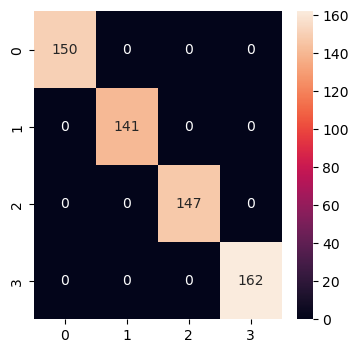

In [19]:
import seaborn as sn

plt.figure(figsize=(4,4))
sn.heatmap(conf_matrix, annot=True,fmt='g')
plt.show()

In [20]:
complaint=['Kindly address the issue of contaminated water, as it poses serious health risks to residents.']
complaintCV=cv.transform(complaint)

model.predict(complaintCV)

array([3])

In [21]:
target_df=pd.DataFrame(target)
data_comp=pd.merge(data.department, target_df, left_index=True, right_index=True)
data_comp[10:20]

,department,0
10,Sanitation Department,2
11,Electricity Department,0
12,Electricity Department,0
13,Electricity Department,0
14,Water Department,3
15,Electricity Department,0
16,Road Department,1
17,Sanitation Department,2
18,Electricity Department,0
19,Sanitation Department,2


In [22]:
complaint=['I would like to bring to your notice the problem of irregular water supply in our area. We have been facing low pressure and shortage of water for the past few days, causing inconvenience in daily activities.']
complaintCV=cv.transform(complaint)

model.predict(complaintCV)

array([3])

In [23]:
complaint=['I am writing to bring to your attention the ongoing issue of improper garbage disposal in our locality. For the past several days, garbage has not been collected regularly, leading to accumulation on the streets and around residential areas.']
complaintCV=cv.transform(complaint)

model.predict(complaintCV)

array([2])

In [24]:
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       150
           1       1.00      1.00      1.00       141
           2       1.00      1.00      1.00       147
           3       1.00      1.00      1.00       162

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

